## Cellpose segmentation for in vitro HEK cells

This script performs automated cell segmentation on in vitro HEK cell datasets using the Cellpose framework. The workflow first extracts image dimensions and organizes data across multiple folders, then computes a maximum-intensity projection (MIP) over the Z-stack for each field of view to obtain a single representative image.

The projected images are segmented using Cellpose to generate masks corresponding to individual cells. These masks are then applied to the two channels, and for each segmented region the corresponding signals are extracted to compute a ratio readout.

The resulting outputs include segmented cell masks and per-cell ratio values, enabling quantitative analysis of ratio fluorescence signals in vitro.

### Required packages

This workflow relies on standard Python libraries for image handling, plotting, tabular output, signal processing, and Cellpose-based segmentation. Required packages can be installed with:

```bash
pip install numpy pandas matplotlib seaborn tifffile scikit-image scipy opencv-python cellpose

In [ ]:
from pathlib import Path
import glob
import os
import re
import cv2
import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile as tiff
from cellpose import models
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from skimage import exposure
from skimage.color import label2rgb

### MIP generation from Z-slices

For each condition, pH, view, and imaging channel, individual TIFF images corresponding to different Z positions are identified from their filenames and grouped into a single Z-stack. Images within each group are sorted by Z index and combined into a 3D array, from which a maximum-intensity projection (MIP) is computed along the Z-axis. This produces one 2D projected image per channel for each field of view. Output files are saved in a structured directory tree organized by condition, pH, and view, and are subsequently used for Cellpose-based segmentation and ratio analysis.

In [ ]:

ROOT = Path("./Example_Raw_images")

pattern = re.compile(
    r".*_(TA|WT)_([0-9]+\.[0-9]+)_v(\d+)_z(\d+)_ch(\d+)\.tif$",
    re.IGNORECASE
)

groups = {}

for file in ROOT.glob("*.tif"):
    m = pattern.match(file.name)
    if not m:
        print(f"Skipping: {file.name}")
        continue

    condition = m.group(1).upper()      
    ph = m.group(2)                     
    view = f"v{m.group(3)}"             
    z = int(m.group(4))                 
    ch = f"ch{m.group(5)}"         

    key = (condition, ph, view, ch)

    if key not in groups:
        groups[key] = []

    groups[key].append((z, file))


for (condition, ph, view, ch), file_list in sorted(groups.items()):
    file_list = sorted(file_list, key=lambda x: x[0]) 

    z_stack = []
    for z, file in file_list:
        img = tiff.imread(file)
        z_stack.append(img)

    z_stack = np.stack(z_stack, axis=0)   
    mip = np.max(z_stack, axis=0)    

    out_dir = ROOT / condition / f"pH_{ph}" / view
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{ch}_MIP.tif"
    tiff.imwrite(out_path, mip.astype(z_stack.dtype))

    print(f"Saved: {out_path}")

### Cellpose segmentation on MIP images

Maximum-intensity projection (MIP) images are segmented using Cellpose. For each experimental condition, the script recursively searches the MIP image directory and selects files corresponding to the user-defined reference channel. Each selected MIP image is loaded as a 2D image and segmented with Cellpose using the specified model configuration and optional GPU acceleration. 

For each segmented image, the output label mask is saved as a NumPy array, and a visualization overlay is generated by superimposing the segmentation labels onto the normalized MIP image. Segmentation results are stored in condition-specific output directories that preserve the original folder hierarchy. These masks are subsequently used for downstream extraction of fluorescence intensities and ratiometric analysis.

In [ ]:
ROOT_DIR    = "./Example_MIP_images"
CHANNEL_TAG = "ch00"      # change to ch01 if needed
MODEL_TAG   = "cyto"
DIAMETER    = None
USE_GPU     = True

model = models.CellposeModel(gpu=USE_GPU)

def run_cellpose(mip_path, save_folder):
    img = tiff.imread(mip_path).astype(np.float32)

    masks, flows, styles = model.eval(
        [img],
        diameter=DIAMETER,
        normalize=True,
        invert=False,
        progress=True,
    )

    mask = masks[0].astype(np.int32)
    n_cells = mask.max()

    os.makedirs(save_folder, exist_ok=True)

    base = os.path.basename(mip_path).replace("_MIP.tif", "")

    np.save(os.path.join(save_folder, f"{base}_labels.npy"), mask)

    img_norm = exposure.rescale_intensity(img, in_range="image", out_range=(0, 1))
    overlay = label2rgb(mask, image=img_norm, alpha=0.4, bg_label=0)
    plt.imsave(os.path.join(save_folder, f"{base}_overlay.png"), np.clip(overlay, 0, 1))

    print(f"Saved: {save_folder} | cells: {n_cells}")

for condition in ["TA", "WT"]:
    input_folder = os.path.join(ROOT_DIR, condition)
    output_folder = os.path.join(ROOT_DIR, f"mask_{condition}")

    for dirpath, dirnames, filenames in os.walk(input_folder):
        for file in filenames:
            if file.endswith("_MIP.tif") and CHANNEL_TAG in file:
                mip_path = os.path.join(dirpath, file)

                rel_path = os.path.relpath(dirpath, input_folder)
                save_folder = os.path.join(output_folder, rel_path)

                print("Running:", mip_path)
                run_cellpose(mip_path, save_folder)

print("Done.")

Done.


### Single-cell intensity filtering, quality control, and ratio extraction

For each condition and field of view, background-corrected single-cell fluorescence intensities are extracted from the channels maximum-intensity projection images using the Cellpose-derived segmentation masks. Background signal in each channel is estimated from pixels outside labeled cells and subtracted prior to quantification. Mean intensities are then calculated for every segmented cell, together with associated metadata including condition, pH, view, and cell area.

To ensure robust ratio measurements, several filtering criteria are applied at the single-cell level. Cells are excluded if the denominator channel (ch00) is too dim relative to background noise, if more than 1% of pixels are saturated in either channel, or if the background-corrected denominator intensity is non-positive. For cells passing these criteria, the fluorescence ratio ch02/ch00 or ch01/ch00 is computed and retained for downstream analysis.

The analysis produces three output tables: filtered single-cell ratios, raw single-cell intensities prior to filtering, and a per-image summary of filtering outcomes. To support quality assessment, the script also generates condition-specific overlaid histograms showing the distributions of channel intensities before and after filtering.

TA | pH_7.29/v5 | total=113 kept=83 dim=30 sat=0 bad_den=0
TA | pH_7.29/v3 | total=80 kept=66 dim=14 sat=0 bad_den=0
TA | pH_7.29/v10 | total=73 kept=64 dim=9 sat=0 bad_den=0
TA | pH_7.29/v2 | total=101 kept=82 dim=19 sat=0 bad_den=0
TA | pH_7.29/v1 | total=56 kept=51 dim=5 sat=0 bad_den=0
TA | pH_7.29/v9 | total=97 kept=79 dim=18 sat=0 bad_den=0
TA | pH_7.29/v7 | total=111 kept=81 dim=30 sat=0 bad_den=0
TA | pH_7.29/v6 | total=76 kept=70 dim=5 sat=1 bad_den=0
TA | pH_7.29/v8 | total=103 kept=79 dim=24 sat=0 bad_den=0
TA | pH_7.29/v4 | total=109 kept=87 dim=22 sat=0 bad_den=0
TA | pH_6.91/v5 | total=73 kept=68 dim=5 sat=0 bad_den=0
TA | pH_6.91/v3 | total=82 kept=71 dim=11 sat=0 bad_den=0
TA | pH_6.91/v10 | total=83 kept=75 dim=8 sat=0 bad_den=0
TA | pH_6.91/v2 | total=75 kept=60 dim=15 sat=0 bad_den=0
TA | pH_6.91/v1 | total=66 kept=59 dim=7 sat=0 bad_den=0
TA | pH_6.91/v9 | total=61 kept=55 dim=6 sat=0 bad_den=0
TA | pH_6.91/v7 | total=85 kept=80 dim=5 sat=0 bad_den=0
TA | pH_6.91/v6

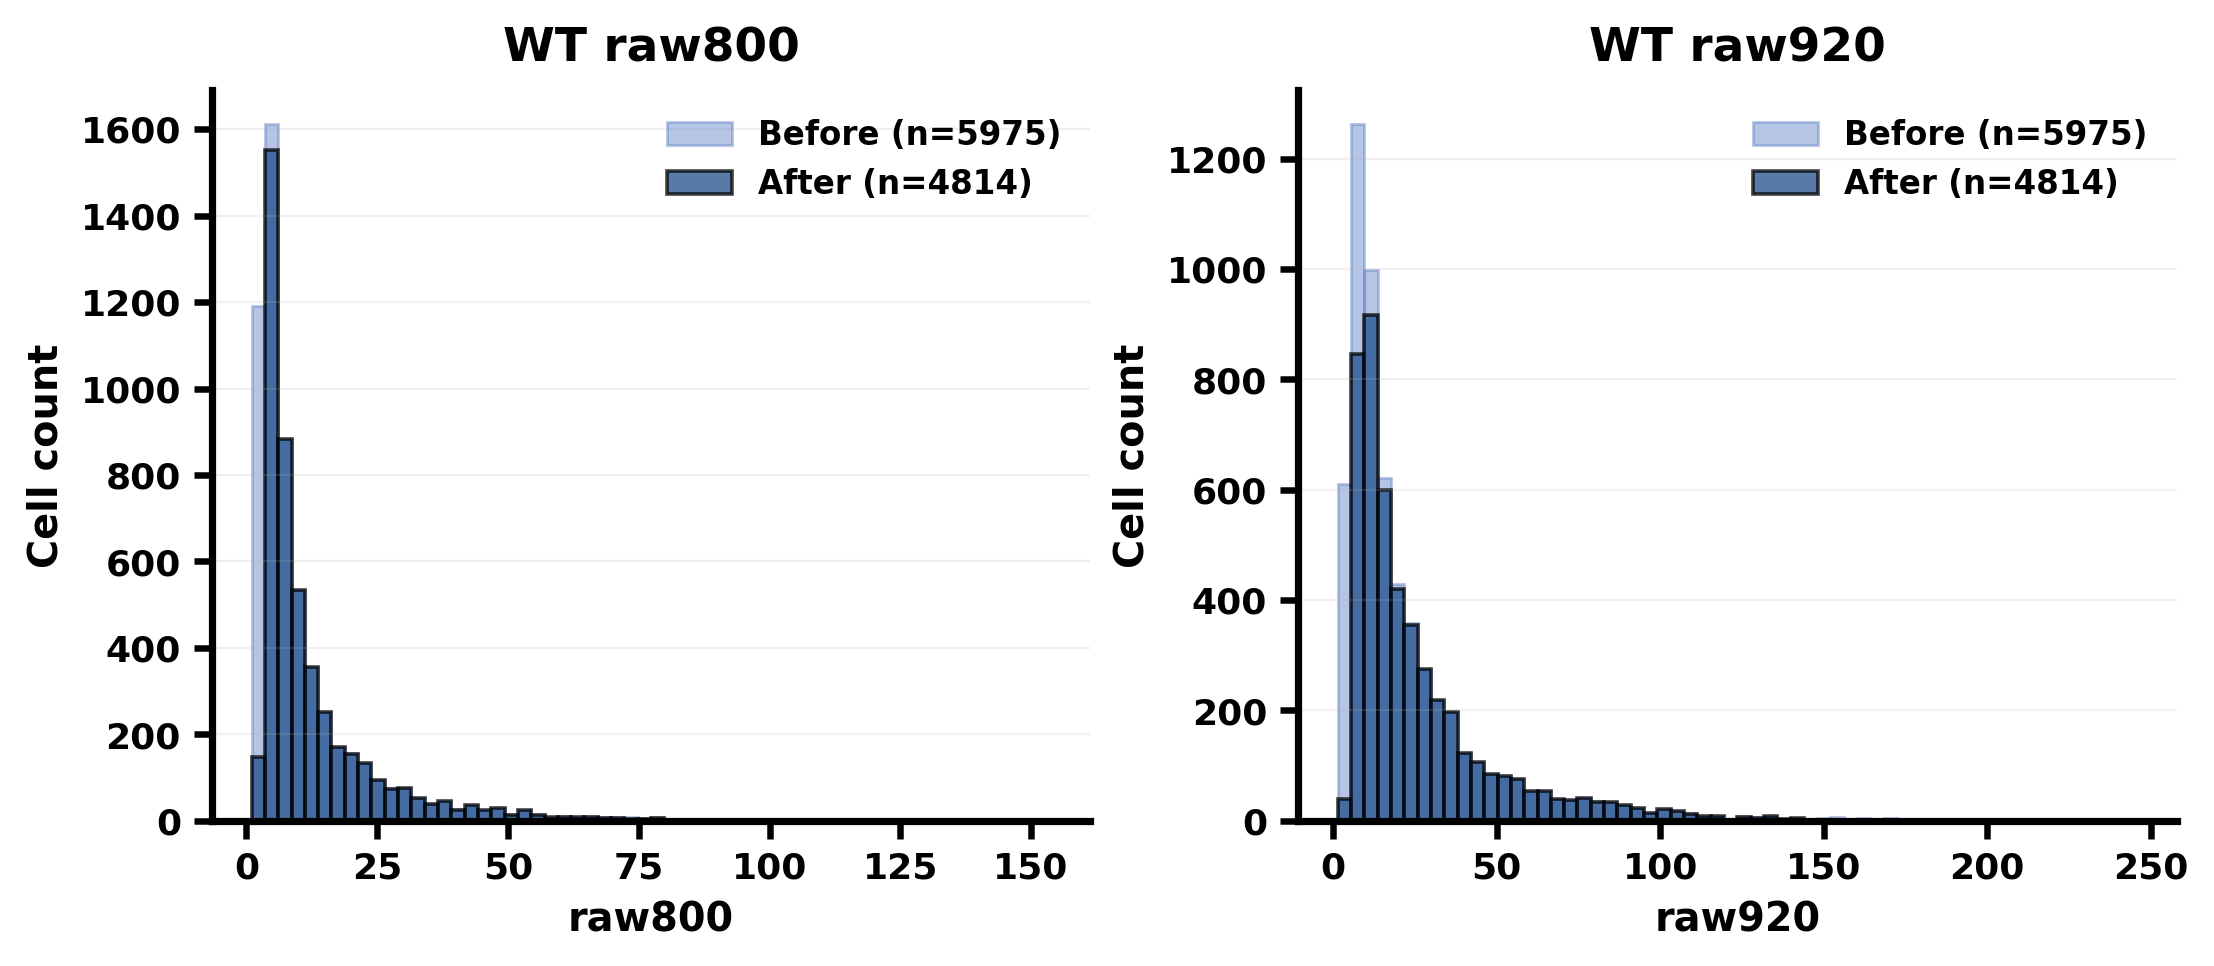

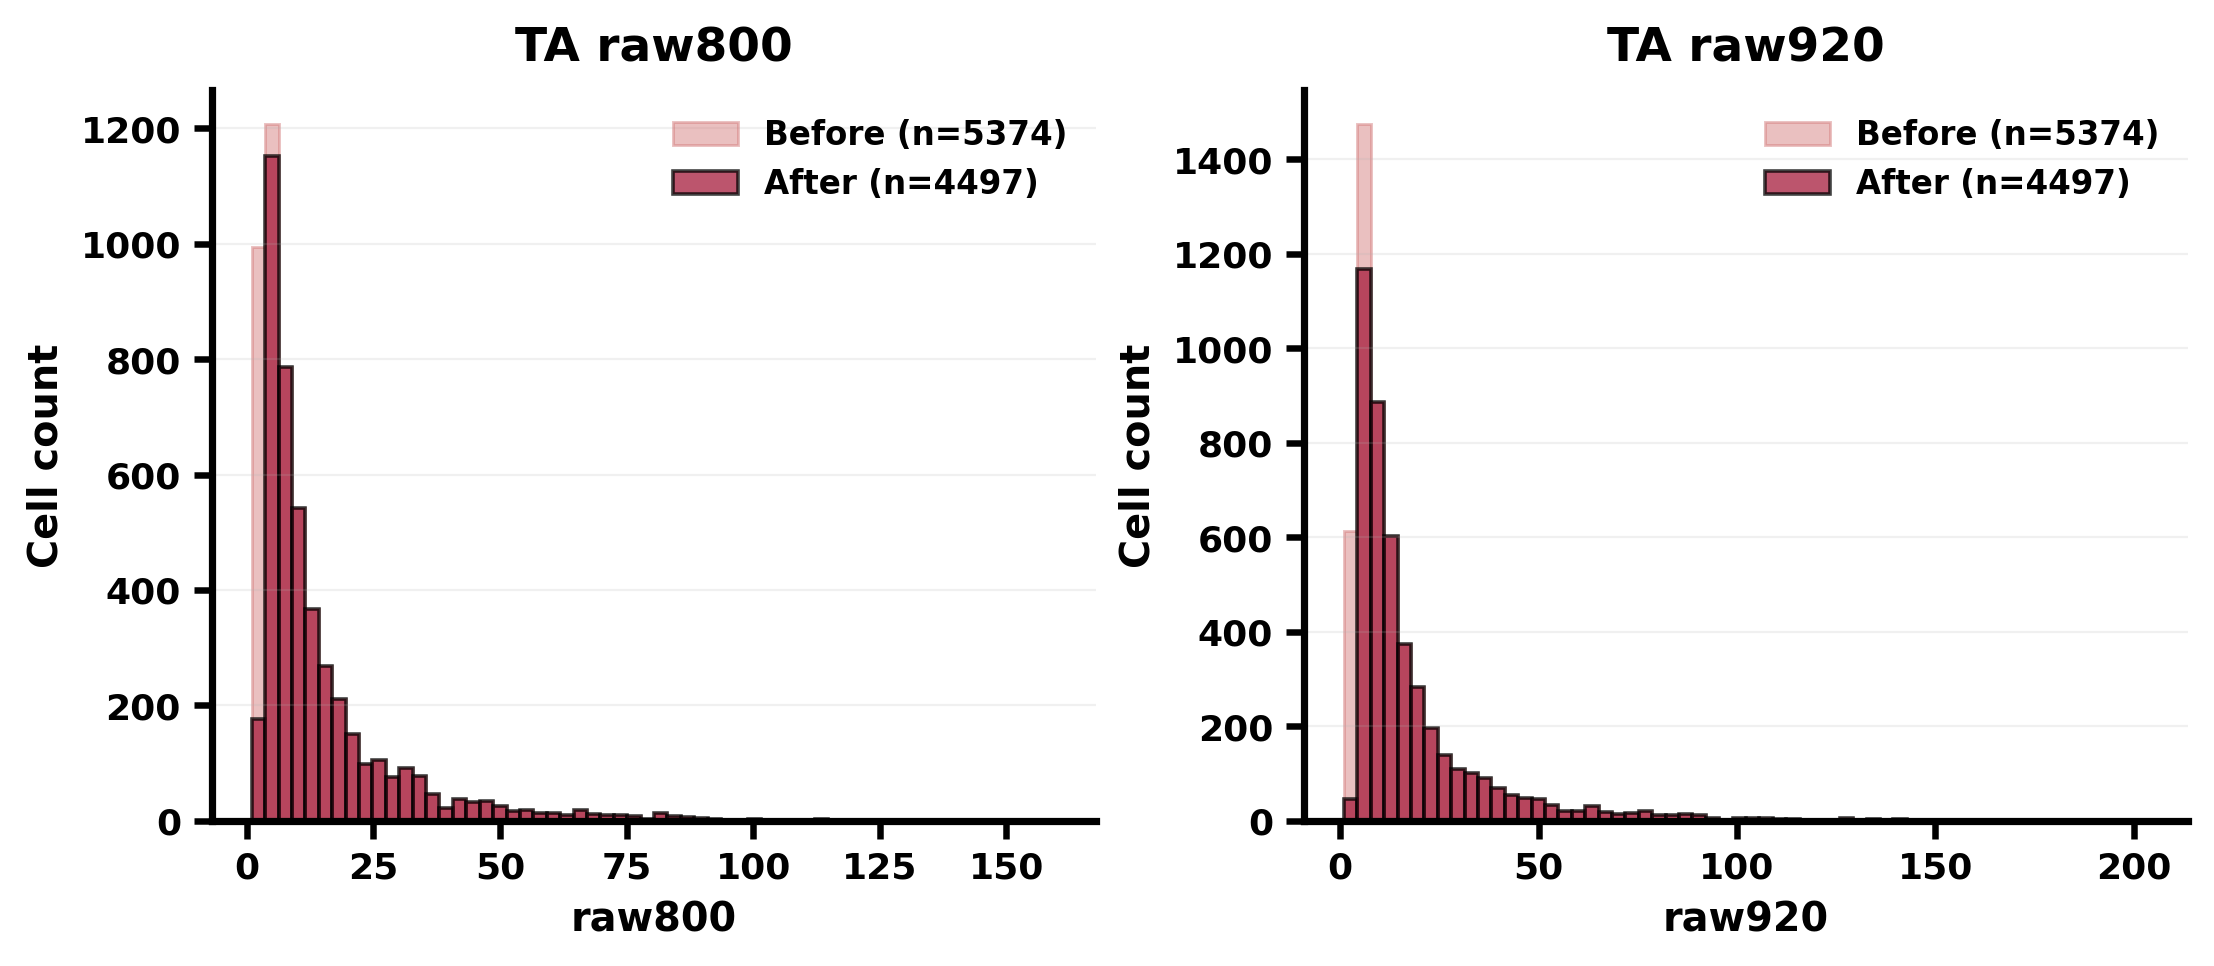

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

ROOT_DIR = "./Example_MIP_images"

rows = []
summary = []
raw_rows = []

def extract_ph(folder):
    m = re.search(r"pH_(\d+\.\d+)", str(folder))
    return float(m.group(1)) if m else np.nan

def extract_view(folder):
    m = re.search(r"(v\d+)", str(folder))
    return m.group(1) if m else ""

for condition in ["TA", "WT"]:
    img_root = os.path.join(ROOT_DIR, condition)
    mask_root = os.path.join(ROOT_DIR, f"mask_{condition}")

    for dirpath, _, filenames in os.walk(img_root):
        rel_path = os.path.relpath(dirpath, img_root)
        mask_dir = os.path.join(mask_root, rel_path)

        if not os.path.isdir(mask_dir):
            continue

        ch0_file = None
        ch1_file = None

        for f in filenames:
            if f.endswith("_MIP.tif") and "ch00" in f:
                ch0_file = os.path.join(dirpath, f)
            if f.endswith("_MIP.tif") and "ch01" in f:
                ch1_file = os.path.join(dirpath, f)

        if ch0_file is None or ch1_file is None:
            continue

        label_files = [f for f in os.listdir(mask_dir) if f.endswith("_labels.npy")]
        if len(label_files) == 0:
            continue

        label_path = os.path.join(mask_dir, label_files[0])

        frame0 = tiff.imread(ch0_file).astype(np.float32)
        frame1 = tiff.imread(ch1_file).astype(np.float32)
        labels = np.load(label_path).astype(np.int32)

        if frame0.shape != frame1.shape or frame0.shape != labels.shape:
            print("Shape mismatch:", rel_path)
            continue

        bg_mask = labels == 0
        if np.sum(bg_mask) == 0:
            continue

        bg0 = np.median(frame0[bg_mask])
        bg1 = np.median(frame1[bg_mask])

        bg_pixels0 = frame0[bg_mask]
        bg0 = np.median(bg_pixels0)

        mad0 = np.median(np.abs(bg_pixels0 - bg0))
        noise0 = 1.4826 * mad0

        if noise0 <= 0:
            lo0, hi0 = np.percentile(bg_pixels0, [5, 95])
            bg_pixels0_clipped = bg_pixels0[(bg_pixels0 >= lo0) & (bg_pixels0 <= hi0)]
            noise0 = np.std(bg_pixels0_clipped)

        if noise0 <= 0:
            noise0 = np.std(bg_pixels0)

        sat0 = 255
        sat1 = 255

        ph_value = extract_ph(rel_path)
        view_value = extract_view(rel_path)

        n_total = 0
        n_kept = 0
        n_dim = 0
        n_sat = 0
        n_bad_den = 0

        for cell_id in np.unique(labels):
            if cell_id == 0:
                continue

            cell_mask = labels == cell_id
            n_total += 1

            pix0 = frame0[cell_mask]
            pix1 = frame1[cell_mask]

            pix0_corr = pix0 - bg0
            pix1_corr = pix1 - bg1

            mean0 = pix0_corr.mean()
            mean1 = pix1_corr.mean()

            # BEFORE FILTERING
            raw_rows.append({
                "condition": condition,
                "folder": rel_path,
                "view": view_value,
                "cell_id": int(cell_id),
                "ch00_mean": float(mean0),
                "ch01_mean": float(mean1),
                "area_px": int(cell_mask.sum())
            })

            if mean0 < 3 * noise0:
                n_dim += 1
                continue

            if np.mean(pix0 >= sat0) > 0.01 or np.mean(pix1 >= sat1) > 0.01:
                n_sat += 1
                continue

            if mean0 <= 0:
                n_bad_den += 1
                continue

            ratio = mean1 / mean0

            rows.append({
                "condition": condition,
                "folder": rel_path,
                "view": view_value,
                "cell_id": int(cell_id),
                "ch00_mean": float(mean0),
                "ch01_mean": float(mean1),
                "ratio_ch01_over_ch00": float(ratio),
                "area_px": int(cell_mask.sum())
            })

            n_kept += 1

        print(f"{condition} | {rel_path} | total={n_total} kept={n_kept} dim={n_dim} sat={n_sat} bad_den={n_bad_den}")

        summary.append({
            "condition": condition,
            "folder": rel_path,
            "view": view_value,
            "n_total": n_total,
            "n_kept": n_kept,
            "n_dim_removed": n_dim,
            "n_sat_removed": n_sat,
            "n_bad_den": n_bad_den
        })

df = pd.DataFrame(rows)
df.to_csv(os.path.join(ROOT_DIR, "single_cell_ratios.csv"), index=False)

df_sum = pd.DataFrame(summary)
df_sum.to_csv(os.path.join(ROOT_DIR, "filtering_summary.csv"), index=False)

print("Saved single_cell_ratios.csv and filtering_summary.csv")

df_raw = pd.DataFrame(raw_rows)
df_raw.to_csv(os.path.join(ROOT_DIR, "single_cell_raw_before_filtering.csv"), index=False)

print("Saved single_cell_raw_before_filtering.csv")

# -----------------------------
# PRETTY OVERLAID HISTOGRAMS: WT and TA, raw800 and raw920
# -----------------------------
def style_prism(ax, title, xlabel, ylabel="Cell count"):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)

    ax.tick_params(axis="both", which="major", width=1.8, length=5, labelsize=10)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.18)
    ax.set_facecolor("white")


def overlay_hist(ax, before_vals, after_vals, bins, title, xlabel, before_color, after_color):
    ax.hist(
        before_vals,
        bins=bins,
        alpha=0.45,
        color=before_color,
        edgecolor=before_color,
        linewidth=0.8,
        label=f"Before (n={len(before_vals)})"
    )

    ax.hist(
        after_vals,
        bins=bins,
        alpha=0.75,
        color=after_color,
        edgecolor="black",
        linewidth=1.0,
        label=f"After (n={len(after_vals)})"
    )

    style_prism(ax, title=title, xlabel=xlabel)
    leg = ax.legend(frameon=False, fontsize=9, loc="upper right")
    for text in leg.get_texts():
        text.set_fontweight("bold")


COLORS = {
    "WT_before": "#6080C5",
    "WT_after":  "#1F4E8C",
    "TA_before": "#D17474",
    "TA_after":  "#A61C3C",
}

N_BINS = 60

for cond in ["WT", "TA"]:
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), dpi=260, constrained_layout=True)

    for ax, col, label in zip(
        axes,
        ["ch00_mean", "ch01_mean"],
        ["raw800", "raw920"]
    ):
        before_vals = df_raw.loc[df_raw["condition"] == cond, col].dropna().values
        after_vals = df.loc[df["condition"] == cond, col].dropna().values

        if len(before_vals) == 0 and len(after_vals) == 0:
            ax.set_visible(False)
            continue

        combined = np.concatenate([
            before_vals if len(before_vals) > 0 else np.array([]),
            after_vals if len(after_vals) > 0 else np.array([])
        ])

        x_min = np.min(combined)
        x_max = np.max(combined)

        if x_min == x_max:
            x_min -= 0.5
            x_max += 0.5

        bins = np.linspace(x_min, x_max, N_BINS + 1)

        overlay_hist(
            ax=ax,
            before_vals=before_vals,
            after_vals=after_vals,
            bins=bins,
            title=f"{cond} {label}",
            xlabel=label,
            before_color=COLORS[f"{cond}_before"],
            after_color=COLORS[f"{cond}_after"]
        )

    plt.show()